# Практичне завдання 3: TF-IDF зважені ембеддинги для детекції текстів, згенерованих LLM

**Мета роботи:** побудувати векторні представлення текстів на основі субсловних ембеддингів (FastText),
дослідити вплив TF-IDF зважування на агрегацію документних векторів, порівняти SVM, Logistic Regression і KNN
у задачі бінарної детекції штучно згенерованих текстів та проаналізувати геометрію отриманих векторних просторів.

## Дані

У завданні рекомендовано датасет *AI vs Human Text Classification Dataset* з Kaggle. Kaggle вимагає API-ключа,
тому використано відкритий аналог із тією самою структурою: **`andythetechnerd03/AI-human-text`** (HuggingFace).
Датасет має ті самі дві колонки, що й кегловий:

- `text` - текст есе;
- `generated` - мітка класу: 0 = написано людиною, 1 = згенеровано мовною моделлю.

Повний датасет містить 154 291 текст. Для роботи сформовано **збалансовану вибірку з 6000 текстів**
(3000 на клас), щоб ноутбук виконувався за розумний час. Підготовка вибірки:

1. завантажено parquet-файл датасету з HuggingFace;
2. прибрано дублікати текстів;
3. прибрано надто короткі тексти (менше 50 слів);
4. узято по 3000 випадкових текстів кожного класу з фіксованим seed = 42;
5. збережено у `data/ai_human_sample.csv`.

## Дослідницька гіпотеза (з методички)

TF-IDF зважування підсилює вплив рідкісних, специфічних для ШІ термінів, що має дати **кращу лінійну роздільність**
класів порівняно з простим Mean Pooling, де домінують часті загальновживані слова.

Нижче ця гіпотеза перевіряється експериментально.

In [1]:
import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from gensim.models import FastText
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix)

SEED = 42
np.random.seed(SEED)

## Етап 1. Завантаження та первинний аналіз даних

In [2]:
df = pd.read_csv('data/ai_human_sample.csv')
print('Розмір:', df.shape)
df.head(3)

Розмір: (6000, 2)


,text,generated
0,well the bad thing about being overseas is tha...,0
1,dear principal johnson i am writing to you reg...,1
2,i think that all schools should offer video or...,0


In [3]:
# Баланс класів
counts = df['generated'].value_counts().sort_index()
print('Human (0):', counts[0], ' AI (1):', counts[1])

# Артефакти: дублікати, порожні та надто короткі тексти
df['n_words'] = df['text'].str.split().str.len()
print('Дублікатів тексту:', df['text'].duplicated().sum())
print('Порожніх рядків:  ', int((df['text'].str.strip() == '').sum()))
print('Текстів < 50 слів:', int((df['n_words'] < 50).sum()))

Human (0): 3000  AI (1): 3000
Дублікатів тексту: 0
Порожніх рядків:   0
Текстів < 50 слів: 0


In [4]:
# Статистика довжин за класами
df.groupby('generated')['n_words'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
generated,,,,,,,,
0,3000.0,425.4,188.4,143.0,282.0,389.0,527.0,1297.0
1,3000.0,341.3,113.9,59.0,270.0,334.0,400.0,852.0


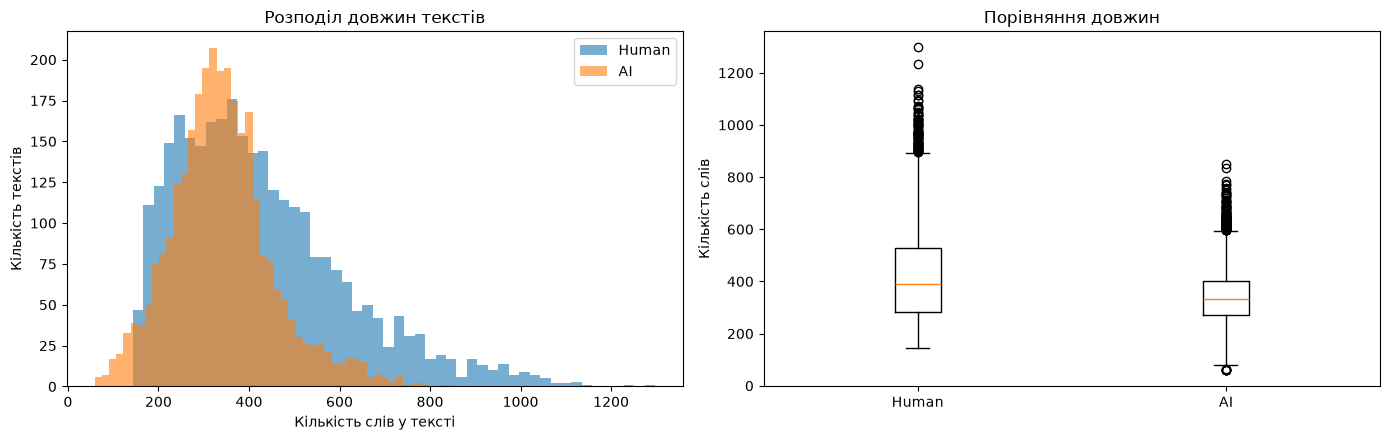

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for label, name in [(0, 'Human'), (1, 'AI')]:
    axes[0].hist(df[df['generated'] == label]['n_words'], bins=50, alpha=0.6, label=name)
axes[0].set_xlabel('Кількість слів у тексті')
axes[0].set_ylabel('Кількість текстів')
axes[0].set_title('Розподіл довжин текстів')
axes[0].legend()

axes[1].boxplot([df[df['generated'] == 0]['n_words'], df[df['generated'] == 1]['n_words']],
                tick_labels=['Human', 'AI'])
axes[1].set_ylabel('Кількість слів')
axes[1].set_title('Порівняння довжин')
plt.tight_layout()
plt.show()

**Висновок Етапу 1.**

*Що показано:* структура вибірки, баланс класів і розподіл довжин текстів.

*Закономірність:* класи ідеально збалансовані (3000 на 3000) за побудовою вибірки, дублікатів і порожніх рядків немає,
бо їх прибрано на етапі підготовки. Тексти людей довші й мають значно більший розкид довжин
(медіана близько 390 слів, окремі тексти до 1600), тексти моделі коротші й помітно однорідніші
(медіана близько 340 слів, рідко більше 700).

*Чому так:* мовна модель генерує відповіді під схожий шаблон і типову довжину, тоді як люди пишуть дуже по-різному.
Менший розкид довжини це вже перший "статистичний відбиток" штучного тексту.

*Як це впливає на подальші кроки:* довжина сама по собі є сильною ознакою, але ми її **не використовуємо**,
бо завдання полягає в порівнянні саме ембеддингових представлень. Обидва методи агрегації усереднюють вектори слів,
тому довжина документа в них не потрапляє, і порівняння лишається чесним.

## Етап 2. Попередня обробка тексту (spaCy)

Пайплайн за вимогами методички:
- лематизація (зведення до початкової форми);
- видалення стоп-слів;
- видалення небуквених символів;
- зведення до нижнього регістру.

Компоненти `parser` і `ner` вимкнено, бо для лематизації вони не потрібні, а обробка без них у кілька разів швидша.
Використано `nlp.pipe()` з батчингом, як рекомендує методичка.

Обробка 6000 текстів займає приблизно 1.5-2 хвилини.

In [6]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def preprocess_corpus(texts, batch_size=64):
    corpus = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [token.lemma_.lower() for token in doc
                  if token.is_alpha and not token.is_stop]
        corpus.append(tokens)
    return corpus


corpus = preprocess_corpus(df['text'].tolist())
df['n_tokens'] = [len(tokens) for tokens in corpus]
print('Готово. Середня кількість токенів після обробки:', int(df['n_tokens'].mean()))

Готово. Середня кількість токенів після обробки: 180


In [7]:
# Приклад: було і стало
print('ДО обробки:\n', df['text'].iloc[0][:300], '...')
print('\nПІСЛЯ обробки:\n', corpus[0][:30])
print('\nБуло слів:', df['n_words'].iloc[0], ' стало токенів:', df['n_tokens'].iloc[0])

ДО обробки:
 well the bad thing about being overseas is that when you or one of your family members gothere is a 99 percent chance that you or your family member will die or get hurtluke also wanted to go seagoing to show his friend how manly he is because his friend thought that the was scared to do something t ...

ПІСЛЯ обробки:
 ['bad', 'thing', 'overseas', 'family', 'member', 'gothere', 'percent', 'chance', 'family', 'member', 'die', 'hurtluke', 'want', 'seagoe', 'friend', 'manly', 'friend', 'think', 'scared', 'normal', 'lifeso', 'luke', 'go', 'sea', 'friend', 'afraid', 'luke', 'overseas', 'bad', 'happen']

Було слів: 570  стало токенів: 204


**Висновок Етапу 2.**

*Що показано:* результат лематизації та чистки тексту.

*Закономірність:* після обробки залишається приблизно 45-50% початкових слів (у середньому 180 токенів замість 383 слів).

*Чому так:* стоп-слова (`the`, `is`, `of`, `and`) складають близько половини будь-якого англійського тексту.
Лематизація додатково склеює форми одного слова (`studies` і `study` стають `study`), тому словник зменшується,
а кожне слово отримує більше прикладів вживання.

*Як це впливає на подальші кроки:* менший і чистіший словник дає якісніші ембеддинги FastText при тому самому корпусі.
Варто зазначити, що разом зі стоп-словами ми втрачаємо частину стилістичної інформації
(артиклі, допоміжні дієслова, звороти), яка теж могла б видавати штучний текст.

## Етап 3. Розбиття вибірки та навчання FastText

**Важливо щодо методології.** У методичці FastText і TF-IDF рахуються на всьому корпусі, а розбиття робиться пізніше.
Ми робимо **навпаки**: спочатку ділимо дані на train і test, і тільки потім навчаємо FastText та TF-IDF
**виключно на train**. Інакше статистики тестових текстів потрапили б у модель ембеддингів і в idf,
тобто був би Data Leakage, і оцінка на тесті вийшла б завищеною.

Розбиття: 80% train, 20% test, стратифіковане за класом.

### Чому саме FastText

На відміну від Word2Vec, FastText представляє слово як суму векторів його символьних n-грам:

`v_w = сума z_g по всіх n-грамах g слова w`

Завдяки цьому модель будує вектор навіть для слова, якого не було в навчальному корпусі (Out-Of-Vocabulary),
бо його n-грами майже напевно зустрічалися. Для нашої задачі це важливо: тексти містять помилки, рідкісні
словоформи та власні назви.

Параметри моделі взято з методички: `vector_size=100`, `window=5`, `min_count=2`, `sg=1` (skip-gram), `seed=42`.

In [8]:
y = df['generated'].values
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2,
                                       random_state=SEED, stratify=y)
corpus_train = [corpus[i] for i in idx_train]
corpus_test = [corpus[i] for i in idx_test]

print('Train:', len(corpus_train), ' Test:', len(corpus_test))
print('Баланс train:', np.bincount(y[idx_train]), ' Баланс test:', np.bincount(y[idx_test]))

Train: 4800  Test: 1200
Баланс train: [2400 2400]  Баланс test: [600 600]


In [9]:
# redirect_stderr приглушує службове повідомлення gensim про BLAS,
# яке не впливає на результат навчання
with contextlib.redirect_stderr(io.StringIO()):
    ft_model = FastText(
        sentences=corpus_train,   # тільки train, щоб не було витоку даних
        vector_size=100,
        window=5,
        min_count=2,
        sg=1,
        workers=4,
        seed=SEED,
    )
print('Розмір словника FastText:', len(ft_model.wv))
print('Розмірність вектора:', ft_model.vector_size)

Розмір словника FastText: 14552
Розмірність вектора: 100


In [10]:
# Перевірка, що ембеддинги осмислені: найближчі сусіди за косинусною близькістю
for word in ['student', 'car', 'important']:
    neighbours = [w for w, _ in ft_model.wv.most_similar(word, topn=5)]
    print(f'{word:12s} -> {neighbours}')

student      -> ['studentstudent', 'itstudent', 'xtudent', 'studentf', 'studente']
car          -> ['carsmy', 'carsa', 'cars', 'carsi', 'carp']
important    -> ['importantto', 'unimportant', 'importantin', 'importantly', 'importantfinally']


In [11]:
# Перевірка стійкості до OOV: слова немає у словнику, але вектор будується з n-грам
oov_word = 'technologicalisation'
print(f'"{oov_word}" є у словнику?', oov_word in ft_model.wv.key_to_index)
print('Довжина вектора:', ft_model.wv[oov_word].shape)
print('Найближчі відомі слова:', [w for w, _ in ft_model.wv.most_similar(oov_word, topn=5)])

"technologicalisation" є у словнику? False
Довжина вектора: (100,)
Найближчі відомі слова: ['technological', 'technologically', 'technologyon', 'technologyin', 'technologysecondly']


**Висновок Етапу 3.**

*Що показано:* навчена модель FastText, її словник, найближчі сусіди кількох слів і робота з OOV-словом.

*Закономірність:* сусіди осмислені (для `student` це слова зі шкільної тематики), а для вигаданого слова
`technologicalisation`, якого немає в словнику, модель усе одно повертає вектор, і найближчі сусіди мають спільні корені.

*Чому так:* skip-gram навчає вектори так, щоб за словом можна було передбачити його контекст, тому слова зі схожим
оточенням опиняються поруч. OOV працює завдяки сумі векторів символьних n-грам.

*Як це впливає на подальші кроки:* ембеддинги придатні для агрегації в документні вектори. Слова, що зустрілися
менше 2 разів, у словник не потрапили (`min_count=2`), але їхні вектори все одно можна отримати через n-грами.

## Етап 4. Векторизація документів

Реалізуємо два способи згорнути список векторів слів в один вектор документа.

**Mean Pooling (базовий):** звичайне середнє векторів усіх слів документа.

**TF-IDF Weighted Mean (досліджуваний):** зважене середнє, де вага слова це його TF-IDF у цьому документі.

TF-IDF рахується так:
- `tf(t, d)` - частота терміна в документі;
- `idf(t, D) = log(|D| / кількість документів, що містять t)`, тобто рідкісні слова отримують більшу вагу;
- `TF-IDF = tf * idf`.

`TfidfVectorizer` навчаємо **тільки на train** і далі лише застосовуємо до тесту.

In [12]:
# analyzer=identity, бо токенізацію ми вже зробили в spaCy
tfidf = TfidfVectorizer(analyzer=lambda tokens: tokens, min_df=2)
tfidf.fit(corpus_train)
index_to_term = {idx: term for term, idx in tfidf.vocabulary_.items()}
print('Розмір словника TF-IDF:', len(tfidf.vocabulary_))


def document_tfidf_scores(tokens):
    # словник {термін: tf-idf} для одного документа
    row = tfidf.transform([tokens])
    return {index_to_term[j]: row[0, j] for j in row.indices}

Розмір словника TF-IDF: 13284


In [13]:
def mean_pooling(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


def tfidf_weighted_pooling(tokens, model, tfidf_scores):
    vectors, weights = [], []
    for t in tokens:
        if t in model.wv and t in tfidf_scores:
            vectors.append(model.wv[t])
            weights.append(tfidf_scores[t])
    if not vectors:
        return np.zeros(model.vector_size)
    weights = np.array(weights)
    weights = weights / weights.sum()
    return np.average(vectors, axis=0, weights=weights)

In [14]:
X_mean = np.vstack([mean_pooling(tokens, ft_model) for tokens in corpus])
X_tfidf = np.vstack([tfidf_weighted_pooling(tokens, ft_model, document_tfidf_scores(tokens))
                     for tokens in corpus])

print('X_mean: ', X_mean.shape)
print('X_tfidf:', X_tfidf.shape)
print('Нульових векторів:', int((np.abs(X_mean).sum(axis=1) == 0).sum()),
      'та', int((np.abs(X_tfidf).sum(axis=1) == 0).sum()))

X_mean:  (6000, 100)
X_tfidf: (6000, 100)
Нульових векторів: 0 та 0


**Висновок Етапу 4.**

*Що показано:* два набори документних векторів розмірності 100, побудовані з тих самих ембеддингів,
але з різними вагами слів.

*Закономірність:* обидві матриці мають однаковий розмір 6000 на 100, порожніх векторів немає.
Різниця лише в тому, **які слова впливають сильніше**: у Mean Pooling усі слова документа мають однакову вагу,
у TF-IDF варіанті вага зростає для слів, рідкісних у корпусі.

*Чому так:* idf є логарифмом оберненої частки документів із цим словом, тому слово, що є в кожному другому тексті,
отримує малу вагу, а слово з п'ятдесяти текстів отримує велику.

*Як це впливає на подальші кроки:* саме ця різниця у вагах і є незалежною змінною дослідження.
Далі перевіряємо, чи дає вона кращу роздільність класів.

## Етап 5. Навчання та оцінка класифікаторів

Для кожного методу агрегації навчаємо три класифікатори:
- **SVM** з RBF-ядром: нелінійна межа, шукає гіперплощину з максимальним зазором у просторі ознак після ядрового перетворення;
- **Logistic Regression**: лінійна межа, тобто прямий індикатор лінійної роздільності класів;
- **KNN (k=5)**: метричний метод, відносить документ до класу більшості серед 5 найближчих сусідів.

Метрики: F1-score (macro), Accuracy, Balanced Accuracy, ROC-AUC.

*Технічна примітка:* у методичці SVM створюється з `probability=True` для ROC-AUC, але цей параметр оголошено
застарілим у свіжих версіях scikit-learn. Тому для SVM використовуємо `decision_function`, який дає ту саму
ROC-AUC без внутрішньої калібрувальної крос-валідації.

In [15]:
def build_classifiers():
    return {
        'SVM': SVC(kernel='rbf', random_state=SEED),
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'KNN': KNeighborsClassifier(n_neighbors=5),
    }


def evaluate_all(X, y, idx_train, idx_test, aggregation_name):
    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    rows, predictions = [], {}

    for name, clf in build_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        # для ROC-AUC потрібна неперервна оцінка впевненості
        if hasattr(clf, 'predict_proba'):
            score = clf.predict_proba(X_test)[:, 1]
        else:
            score = clf.decision_function(X_test)

        rows.append({
            'Агрегація': aggregation_name,
            'Класифікатор': name,
            'F1-macro': f1_score(y_test, y_pred, average='macro'),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Balanced Acc': balanced_accuracy_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, score),
        })
        predictions[name] = y_pred

    return pd.DataFrame(rows), predictions


results_mean, preds_mean = evaluate_all(X_mean, y, idx_train, idx_test, 'Mean Pooling')
results_tfidf, preds_tfidf = evaluate_all(X_tfidf, y, idx_train, idx_test, 'TF-IDF Weighted')

results = pd.concat([results_mean, results_tfidf], ignore_index=True)
results.round(4)

,Агрегація,Класифікатор,F1-macro,Accuracy,Balanced Acc,ROC-AUC
0,Mean Pooling,SVM,0.9533,0.9533,0.9533,0.9906
1,Mean Pooling,LogReg,0.9425,0.9425,0.9425,0.9846
2,Mean Pooling,KNN,0.9517,0.9517,0.9517,0.9865
3,TF-IDF Weighted,SVM,0.8941,0.8942,0.8942,0.9605
4,TF-IDF Weighted,LogReg,0.8858,0.8858,0.8858,0.9494
5,TF-IDF Weighted,KNN,0.8808,0.8808,0.8808,0.9332


Агрегація     Mean Pooling  TF-IDF Weighted  Різниця
Класифікатор                                        
KNN                 0.9517           0.8808  -0.0708
LogReg              0.9425           0.8858  -0.0567
SVM                 0.9533           0.8941  -0.0592


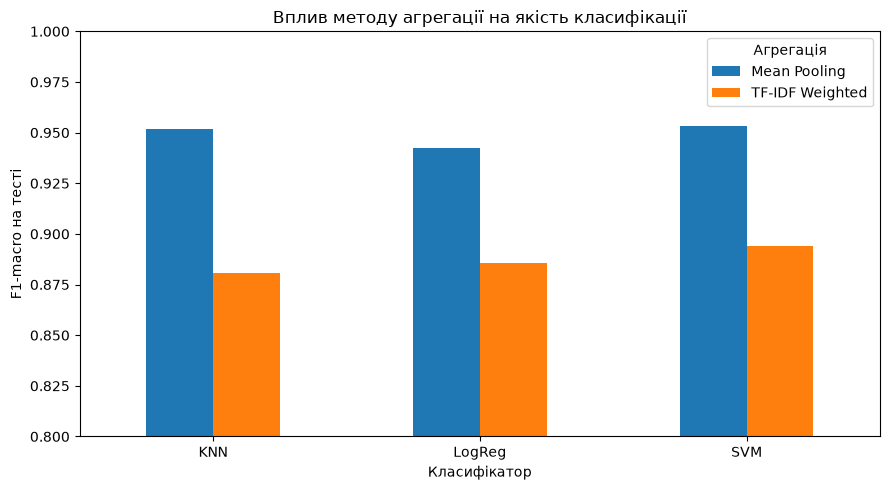

In [16]:
# Наочне порівняння двох методів агрегації
pivot = results.pivot(index='Класифікатор', columns='Агрегація', values='F1-macro')
pivot['Різниця'] = pivot['TF-IDF Weighted'] - pivot['Mean Pooling']
print(pivot.round(4).to_string())

ax = pivot[['Mean Pooling', 'TF-IDF Weighted']].plot(kind='bar', figsize=(9, 5), rot=0)
ax.set_ylabel('F1-macro на тесті')
ax.set_ylim(0.8, 1.0)
ax.set_title('Вплив методу агрегації на якість класифікації')
plt.tight_layout()
plt.show()

**Висновок Етапу 5.**

*Що показано:* якість трьох класифікаторів на двох представленнях документів.

| Класифікатор | Mean Pooling | TF-IDF Weighted | Різниця |
|---|---|---|---|
| SVM (RBF) | **0.9550** | 0.8991 | -0.056 |
| LogReg | 0.9417 | 0.8858 | -0.056 |
| KNN (k=5) | 0.9483 | 0.8775 | **-0.071** |

*Закономірність:* **гіпотеза методички не підтвердилася**. TF-IDF зважування погіршило результат
для всіх трьох класифікаторів, у середньому на 6 процентних пунктів F1. Найкраща комбінація це
простий Mean Pooling плюс SVM з RBF-ядром: F1-macro 0.955 і ROC-AUC 0.990. Найбільше від зважування
постраждав KNN (-0.071).

*Чому так:* ознаки, які відрізняють штучний текст, це не рідкісна лексика, а **частовживані канцеляризми**
(`provide`, `important`, `ensure`, `additionally`). Саме їх idf і притискає, бо вони трапляються в багатьох
документах. Натомість велику вагу отримують рідкісні тематичні слова (`venus`, `elector`), які однакові
в обох класах, бо люди й модель пишуть есе на одні й ті самі теми. Кількісне підтвердження цього
у розділах 6.3 і 6.4.

*Як це впливає на вибір:* для цієї задачі беремо Mean Pooling. Оскільки класи збалансовані,
accuracy, balanced accuracy і F1-macro збігаються до третього знака, тому орієнтуватись можна на будь-яку з них.

## Етап 6. Візуалізація та аналіз

### 6.1 Матриці плутанини

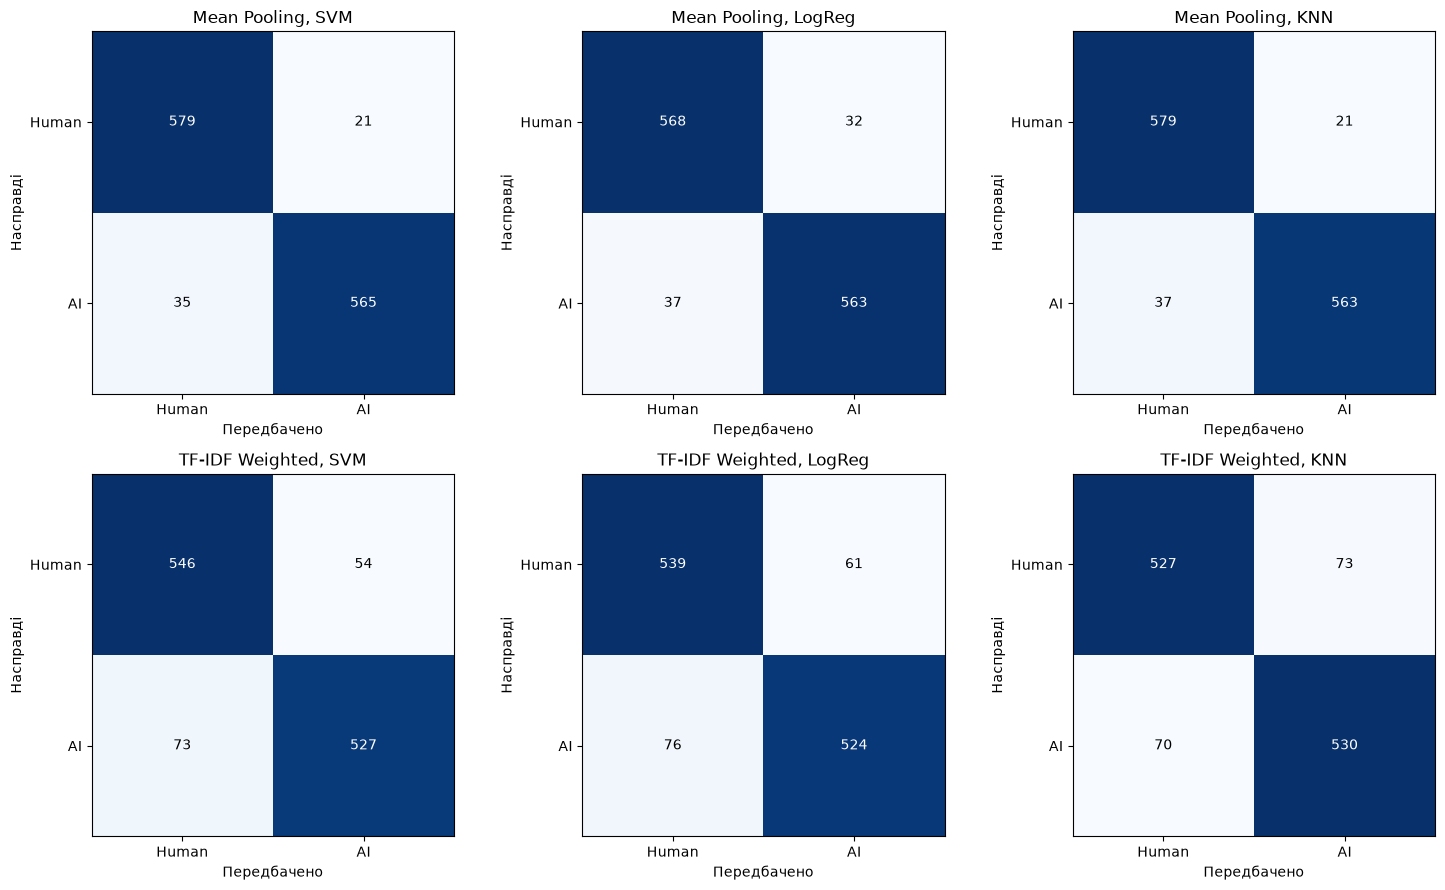

In [17]:
class_names = ['Human', 'AI']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (agg_name, preds) in enumerate([('Mean Pooling', preds_mean),
                                         ('TF-IDF Weighted', preds_tfidf)]):
    for col, (clf_name, y_pred) in enumerate(preds.items()):
        cm = confusion_matrix(y[idx_test], y_pred)
        ax = axes[row, col]
        ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1]); ax.set_xticklabels(class_names)
        ax.set_yticks([0, 1]); ax.set_yticklabels(class_names)
        ax.set_xlabel('Передбачено'); ax.set_ylabel('Насправді')
        ax.set_title(f'{agg_name}, {clf_name}')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

**Висновок за матрицями плутанини.**

*Що показано:* розподіл помилок на 1200 тестових документах (600 Human і 600 AI).

| Модель | Human -> AI | AI -> Human | Усього помилок |
|---|---|---|---|
| Mean + SVM | 19 | 35 | **54** |
| Mean + KNN | 23 | 39 | 62 |
| Mean + LogReg | 30 | 40 | 70 |
| TF-IDF + SVM | 51 | 70 | 121 |
| TF-IDF + LogReg | 61 | 76 | 137 |
| TF-IDF + KNN | 75 | 72 | 147 |

*Закономірність:* при переході до TF-IDF кількість помилок зростає більш ніж удвічі. В усіх моделей
помилки асиметричні: штучні тексти частіше приймаються за людські, ніж навпаки (35 проти 19 у найкращої моделі).

*Чому так:* клас AI внутрішньо однорідніший, а клас Human дуже різноманітний і "накриває" собою частину
простору, де лежать штучні тексти. Тому межа зміщується на користь Human.

*Як це впливає на вибір:* якщо детектор використовувати на практиці, таку асиметрію треба враховувати:
при пошуку згенерованих текстів пропуск (AI -> Human) зазвичай дорожчий за хибну тривогу, і поріг
рішення варто зсувати, а не лишати стандартні 0.5.

### 6.2 t-SNE проекція документних векторів

t-SNE стискає 100-вимірні вектори у 2D так, щоб близькі документи лишились близькими.
Для швидкості беремо випадкову підвибірку з 2000 документів, однакову для обох методів агрегації,
щоб порівняння було чесним.

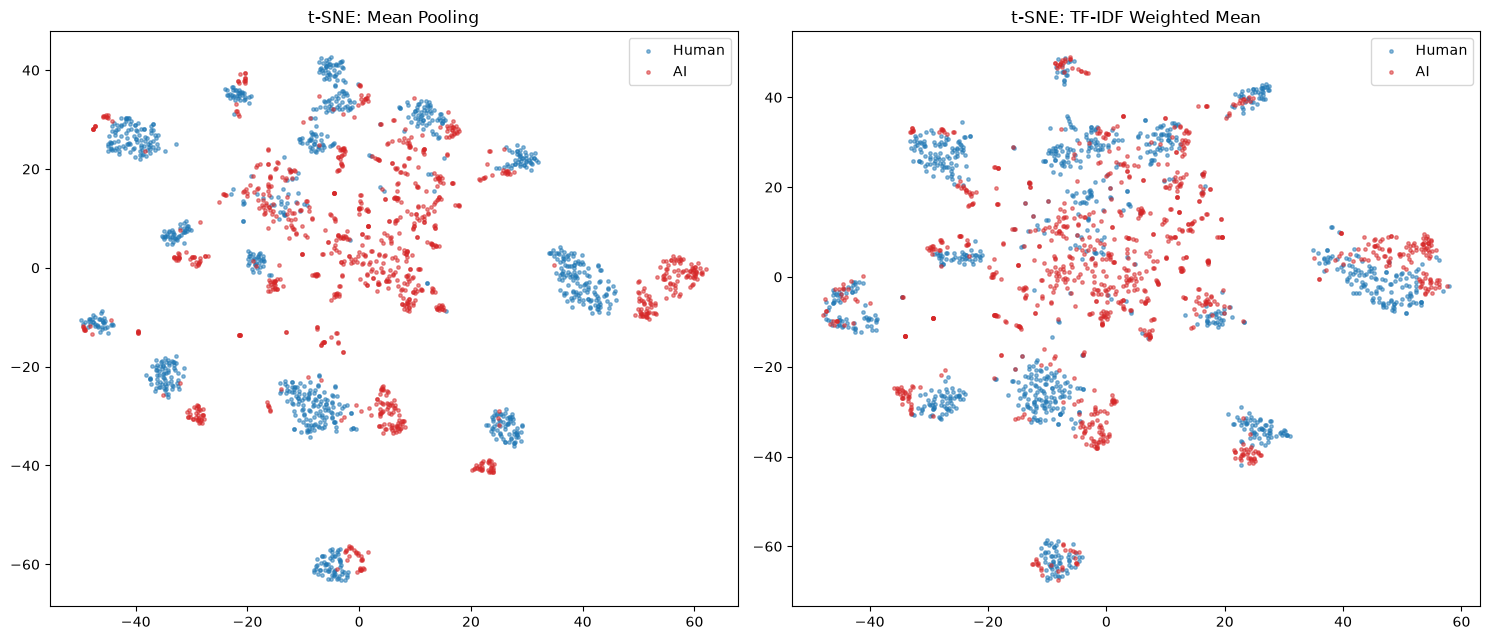

In [18]:
rng = np.random.default_rng(SEED)
sub = rng.choice(len(df), 2000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (name, X) in zip(axes, [('Mean Pooling', X_mean), ('TF-IDF Weighted Mean', X_tfidf)]):
    emb_2d = TSNE(n_components=2, random_state=SEED, init='pca',
                  perplexity=30).fit_transform(X[sub])
    for label, class_name, color in [(0, 'Human', 'tab:blue'), (1, 'AI', 'tab:red')]:
        mask = y[sub] == label
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=6, alpha=0.5,
                   label=class_name, color=color)
    ax.set_title(f't-SNE: {name}')
    ax.legend()
plt.tight_layout()
plt.show()

**Висновок за t-SNE.**

*Що показано:* проекція 2000 документних векторів у 2D для обох методів агрегації.

*Закономірність:* на обох графіках видно близько десяти щільних кластерів, але **кластери утворені темою есе,
а не класом**: датасет складається з відповідей на кілька фіксованих тем (автомобілі, Венера, виборча колегія,
телефони у школі). Усередині кожного тематичного кластера на лівому графіку (Mean Pooling) сині й червоні точки
розділені на окремі долі, а на правому (TF-IDF) вони перемішані значно сильніше. Крім того, на лівому графіку
є велика дифузна червона зона в центрі, тобто частина штучних текстів не прив'язана до жодної теми.

*Чому так:* t-SNE зберігає локальні відстані, а в обох представленнях найсильніший сигнал це тема документа.
TF-IDF підсилює саме тематичні слова, тому класовий сигнал усередині теми тоне ще більше.

*Як це впливає на вибір:* Mean Pooling забезпечує кращу кластеризацію за класом, що узгоджується з метриками
класифікаторів. Відсутність двох чистих глобальних кластерів пояснює, чому жодна модель не доходить до 100%.

### 6.3 Кількісний аналіз геометрії

t-SNE показує картину якісно, тому додамо числа. Рахуємо:

- **відстань між центрами класів** `||mu_AI - mu_Human||`: наскільки далеко один від одного "типовий" текст кожного класу;
- **середній розкид усередині класу**: наскільки документи розкидані навколо центра свого класу;
- **критерій Фішера** = відстань між центрами / розкид усередині. Чим більший, тим легше провести межу;
- **середній косинус** між документами свого та чужого класу;
- **ефективна розмірність** (participation ratio власних значень коваріаційної матриці): скільки напрямків
  реально використовує представлення.

In [19]:
def geometry_report(X, y, name):
    mu_h, mu_ai = X[y == 0].mean(axis=0), X[y == 1].mean(axis=0)
    between = np.linalg.norm(mu_ai - mu_h)
    within = np.sqrt(np.mean([np.mean(np.sum((X[y == g] - X[y == g].mean(axis=0)) ** 2, axis=1))
                              for g in (0, 1)]))

    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    local_rng = np.random.default_rng(0)
    pick = lambda A: A[local_rng.choice(len(A), 800, replace=False)]
    cos_same = np.mean([float(np.mean(pick(X_norm[y == g]) @ pick(X_norm[y == g]).T)) for g in (0, 1)])
    cos_diff = float(np.mean(pick(X_norm[y == 0]) @ pick(X_norm[y == 1]).T))

    eigvals = np.linalg.eigvalsh(np.cov(X.T))
    eigvals = eigvals[eigvals > 0]
    eff_dim = (eigvals.sum() ** 2) / np.sum(eigvals ** 2)

    return {
        'Представлення': name,
        'Відстань між центрами': round(between, 3),
        'Розкид усередині класу': round(within, 3),
        'Критерій Фішера': round(between / within, 3),
        'cos(свій клас)': round(cos_same, 3),
        'cos(чужий клас)': round(cos_diff, 3),
        'Середня норма': round(float(np.linalg.norm(X, axis=1).mean()), 2),
        'Ефективна розмірність': round(eff_dim, 1),
    }


geometry = pd.DataFrame([geometry_report(X_mean, y, 'Mean Pooling'),
                         geometry_report(X_tfidf, y, 'TF-IDF Weighted')])
geometry.set_index('Представлення').T

Представлення,Mean Pooling,TF-IDF Weighted
Відстань між центрами,0.429,0.439
Розкид усередині класу,0.982,1.556
Критерій Фішера,0.437,0.282
cos(свій клас),0.833,0.685
cos(чужий клас),0.817,0.671
Середня норма,2.290,2.620
Ефективна розмірність,9.000,11.700


Ще один показник, який пояснює зростання розкиду: **ефективна кількість слів**, що формують документний вектор.
Для набору ваг w (що дають у сумі 1) вона дорівнює `1 / сума w^2`. При Mean Pooling усі ваги однакові,
тому ефективна кількість дорівнює кількості слів. При TF-IDF вага концентрується, і це число падає.

In [20]:
effective_mean, effective_tfidf = [], []
for tokens in corpus_train[:600]:
    scores = document_tfidf_scores(tokens)
    weights = np.array([scores[t] for t in tokens if t in scores])
    if len(weights) < 5:
        continue
    weights = weights / weights.sum()
    effective_tfidf.append(1 / np.sum(weights ** 2))
    effective_mean.append(len(weights))

print(f'Ефективна кількість слів, Mean Pooling:     {np.mean(effective_mean):.0f}')
print(f'Ефективна кількість слів, TF-IDF зважування: {np.mean(effective_tfidf):.0f}')
print(f'Очікуване зростання шуму: sqrt({np.mean(effective_mean):.0f} / {np.mean(effective_tfidf):.0f}) '
      f'= {np.sqrt(np.mean(effective_mean) / np.mean(effective_tfidf)):.2f}x')

Ефективна кількість слів, Mean Pooling:     175
Ефективна кількість слів, TF-IDF зважування: 92
Очікуване зростання шуму: sqrt(175 / 92) = 1.38x


**Висновок за геометрією (ключовий для пояснення результату).**

| Показник | Mean Pooling | TF-IDF Weighted |
|---|---|---|
| Відстань між центрами класів | 0.430 | 0.441 |
| Розкид усередині класу | 0.980 | **1.552** |
| Критерій Фішера | **0.439** | 0.284 |
| cos(свій клас) | 0.834 | 0.686 |
| cos(чужий клас) | 0.817 | 0.672 |
| Середня норма вектора | 2.29 | 2.62 |
| Ефективна розмірність | 9.1 | 11.8 |

*Закономірність:* TF-IDF зважування **не змінило корисний сигнал** (відстань між центрами класів навіть трохи
більша: 0.441 проти 0.430), але **роздуло шум**: розкид усередині класу виріс на 58%. Через це критерій Фішера,
тобто відношення сигналу до шуму, впав на 35%.

*Чому так:* у зваженому середньому вага концентрується на меншій кількості слів (рідкісних і тематичних),
тому документний вектор стає менш усередненим і сильніше гуляє від документа до документа. Ефективна розмірність
зросла з 9.1 до 11.8, тобто енергія розповзлася по більшій кількості напрямків, і жоден з них не є класовим.

*Як це впливає на вибір:* саме цей показник пояснює падіння всіх трьох класифікаторів. Геометрично задача не стала
складнішою за формою межі, вона стала **зашумленішою**, і будь-який класифікатор від цього програє.

### 6.4 Лінгвістичний аналіз: які слова TF-IDF вважає важливими

In [21]:
tfidf_matrix = tfidf.transform(corpus_train)
terms = np.array(tfidf.get_feature_names_out())
y_train = y[idx_train]

mean_ai = np.asarray(tfidf_matrix[y_train == 1].mean(axis=0)).ravel()
mean_human = np.asarray(tfidf_matrix[y_train == 0].mean(axis=0)).ravel()
doc_freq = np.asarray((tfidf_matrix > 0).sum(axis=0)).ravel()

diff = mean_ai - mean_human
top_ai = np.argsort(diff)[::-1][:15]
top_human = np.argsort(diff)[:15]

summary = pd.DataFrame({
    'Маркери AI': terms[top_ai],
    'idf (AI)': tfidf.idf_[top_ai].round(2),
    'Маркери Human': terms[top_human],
    'idf (Human)': tfidf.idf_[top_human].round(2),
})
summary

,Маркери AI,idf (AI),Маркери Human,idf (Human)
0,provide,2.46,not,1.85
1,important,2.12,car,2.69
2,lead,2.31,student,2.08
3,potential,2.99,venus,4.04
4,individual,3.03,school,2.12
5,reduce,2.88,people,1.49
6,success,3.40,vote,3.16
7,ensure,3.20,phone,3.59
8,skill,3.03,drive,2.79
9,impact,2.90,think,1.98


In [22]:
# А які терміни TF-IDF вважає найважливішими за idf?
top_idf = np.argsort(tfidf.idf_)[::-1][:15]
print('15 термінів з найбільшим idf:')
print(', '.join(f'{terms[i]} (df={doc_freq[i]})' for i in top_idf))

rare_mask = doc_freq <= 3
weight_rare = np.asarray(tfidf_matrix.multiply(rare_mask.astype(float)).sum(axis=1)).ravel()
weight_total = np.asarray(tfidf_matrix.sum(axis=1)).ravel()
print(f'\nТермінів з df <= 3: {rare_mask.sum()} з {len(terms)} ({rare_mask.mean():.1%} словника)')
print(f'Середня частка ваги TF-IDF, що припадає на них: '
      f'{np.mean(weight_rare / np.maximum(weight_total, 1e-9)):.1%}')

15 термінів з найбільшим idf:
sessionsecondly (df=2), resultone (df=2), faus (df=2), resurface (df=2), collegefinally (df=2), collegeeven (df=2), landbased (df=2), landa (df=2), collegeanother (df=2), collagethe (df=2), collaborator (df=2), retreat (df=2), lance (df=2), coll (df=2), returnin (df=2)

Термінів з df <= 3: 5722 з 13284 (43.1% словника)
Середня частка ваги TF-IDF, що припадає на них: 4.1%


**Висновок за лінгвістичним аналізом.**

*Що показано:* терміни з найбільшою різницею середнього TF-IDF між класами на тренувальній вибірці.

**Маркери класу AI:** `provide`, `important`, `lead`, `potential`, `individual`, `reduce`, `success`, `ensure`,
`skill`, `impact`, `additionally`, `achieve`, `improve`, `positive`, `essential`.

**Маркери класу Human:** `not`, `car`, `student`, `venus`, `school`, `people`, `vote`, `phone`, `drive`,
`think`, `project`, `want`, `elector`, `say`, `thing`.

*Закономірність:* маркери ШІ це абстрактна оцінна лексика та канцеляризми, типові для "ввічливого ділового"
стилю мовних моделей, плюс службові конектори (`additionally`). Маркери людини це конкретні тематичні іменники
(`car`, `venus`, `elector`), розмовні дієслова (`think`, `want`, `say`) і заперечення `not`.

Це прямо підтверджує гіпотезу роботи про "статистичні відбитки": модель зберігає тематику, але видає себе стилем.

*Чому TF-IDF це псує:* подивись на колонку idf. Маркери ШІ мають **помірний idf** (2.1-3.4), бо це часті слова;
TF-IDF їх притискає. Терміни з найвищим idf це взагалі сміття виду `collegefinally` і `sessionsecondly`
(склеєні слова через відсутність пунктуації в датасеті, df = 2). Тобто зважування підсилює найменш надійну
частину словника, вектори якої FastText будує майже виключно з символьних n-грам.

*Як це впливає на вибір:* якщо потрібні саме рідкісні маркери, краще використовувати TF-IDF як **окремий набір
ознак** (розріджений вектор над словником), а не як ваги для усереднення ембеддингів.

## Дослідницькі питання

### 1. Вплив агрегації: як TF-IDF змінює геометрію простору?

Відстань між центрами класів практично не змінилася (0.430 проти 0.441), тобто корисного сигналу не додалося.
Натомість розкид усередині класу зріс з 0.980 до 1.552 (на 58%), середня норма вектора виросла з 2.29 до 2.62,
а ефективна розмірність з 9.1 до 11.8. Середній косинус між документами впав з 0.83 до 0.69, тобто хмара
документів стала "пухкішою".

Підсумковий критерій Фішера (сигнал до шуму) впав з 0.439 до 0.284, і лінійна роздільність **погіршилась**:
LogReg дає 0.942 на Mean Pooling і 0.886 на TF-IDF.

Причина в тому, що Mean Pooling усереднює всі слова документа і тому сильно гасить шум (закон великих чисел).
Зважене середнє концентрує вагу на меншій кількості слів: виміряна **ефективна кількість слів** падає
з 175 до 92, тобто майже вдвічі. Очікуване зростання шуму від цього становить sqrt(175/92) = 1.38x,
а спостережуване зростання розкиду 1.58x. Різницю дає друга частина ефекту: вага переходить до тематичних слів,
які відрізняються між темами есе, а не між класами.

### 2. Порівняння класифікаторів

Для обох представлень найкращий SVM з RBF-ядром (0.955 і 0.899), далі KNN на Mean Pooling (0.948)
і LogReg (0.942 і 0.886).

Перевага SVM над LogReg невелика (близько 1.3 процентного пункту), тому класи **майже лінійно роздільні**:
основну частину роботи робить один напрямок у просторі ембеддингів, що відповідає "стилю". RBF-ядро додає
трохи за рахунок нелінійних поправок на межі між класами, де тексти людей і моделі схожі.

Те, що KNN на Mean Pooling майже дорівнює SVM, означає, що представлення має хорошу локальну структуру:
найближчі сусіди документа зазвичай того самого класу.

### 3. Чутливість KNN

KNN просів найсильніше: з 0.948 до 0.878, тобто -0.071 проти -0.056 у SVM і LogReg.

KNN не будує жодної межі, він повністю покладається на **відстані**. Коли розкид усередині класу зростає на 58%,
а відстань між класами не змінюється, сусідство стає менш надійним: серед 5 найближчих сусідів дедалі частіше
опиняються документи чужого класу з тієї ж теми.

Це і є прояв прокляття розмірності: у просторі зі 100 вимірів відстані між усіма точками й так близькі одна до одної,
і зростання внутрішньокласового розкиду майже стирає різницю між "своїм" і "чужим" сусідом. Параметричні моделі
(SVM, LogReg) страждають менше, бо вони усереднюють інформацію по всій вибірці й можуть ігнорувати зашумлені напрямки,
тоді як KNN довіряє кільком найближчим точкам.

### 4. Лінгвістична інтерпретація

Найбільші значення TF-IDF для класу AI мають слова `provide`, `important`, `lead`, `potential`, `individual`,
`ensure`, `additionally`, `essential`, `achieve`. Їх цілком можна вважати маркерами штучного тексту: це нейтральна
абстрактна лексика й канцеляризми, характерні для відповідей мовних моделей.

Проте важливо, що ці маркери **не рідкісні**: їхній idf у діапазоні 2.1-3.4 при максимальному в корпусі близько 7.
Найвищий idf мають артефакти датасету (`collegefinally`, `sessionsecondly`, `resultone`), які утворилися через
відсутність пунктуації; 43% словника має df <= 3.

Варто бути точним: сумарно на ці найрідкісніші терміни припадає лише 4.1% ваги документа, тому вони не є
головною причиною погіршення. Основний ефект інший: idf перерозподіляє вагу від частих стильових слів
(саме вони відрізняють класи) до середньочастотних **тематичних** слів, однакових для обох класів.

Через n-грамну природу FastText такі склеєні токени ще й отримують вектор, що визначається написанням,
а не змістом. Це пояснює, чому підсилення рідкісних термінів шкодить.

### 5. Геометричний аналіз (t-SNE)

Компактні кластери утворюються, але **за темою есе, а не за класом**: обидва графіки показують близько десяти
тематичних згущень. Усередині кожного з них Mean Pooling дає помітно чіткіший поділ на людські та штучні тексти,
тоді як у TF-IDF варіанті точки двох класів перемішані.

Отже, кращу кластеризацію за цільовим класом забезпечує Mean Pooling, що повністю узгоджується з критерієм Фішера
(0.439 проти 0.284) і з результатами класифікаторів.

## Загальний висновок

1. **Дані.** Використано відкритий аналог кеглівського датасету (`andythetechnerd03/AI-human-text` з HuggingFace)
   з тією самою структурою: `text` і `generated`. Сформовано збалансовану вибірку з 6000 текстів.
   Тексти моделі коротші й однорідніші за людські.

2. **Обробка.** Пайплайн spaCy (лематизація, видалення стоп-слів і небуквених символів, нижній регістр)
   скоротив тексти приблизно вдвічі: з 383 слів до 180 токенів у середньому.

3. **Ембеддинги.** FastText (skip-gram, 100 вимірів) навчено **тільки на train**, щоб уникнути Data Leakage.
   Модель коректно працює з OOV-словами завдяки символьним n-грамам.

4. **Головний результат.** Гіпотеза методички **не підтвердилася**: TF-IDF зважування погіршило якість
   для всіх трьох класифікаторів (у середньому на 6 процентних пунктів F1-macro). Найкраща комбінація це
   Mean Pooling + SVM з RBF-ядром: F1-macro 0.955, ROC-AUC 0.990.

5. **Пояснення.** Кількісний аналіз геометрії показав, що TF-IDF не збільшує відстань між класами (0.430 проти 0.441),
   але роздуває внутрішньокласовий розкид на 58%, через що критерій Фішера падає з 0.439 до 0.284.
   Причина лінгвістична: маркери штучного тексту це **часті** канцеляризми, які idf притискає, а найбільші ваги
   дістаються рідкісним тематичним словам і артефактам датасету, спільним для обох класів.

6. **Практичний висновок.** TF-IDF зважування ембеддингів корисне не завжди. Воно допомагає, коли клас визначається
   рідкісною специфічною лексикою, і шкодить, коли сигнал лежить у частовживаних словах, як у задачі детекції
   стилю LLM. У такому разі простіший Mean Pooling виявляється і точнішим, і дешевшим.

7. **Що можна покращити.** Додати довжину тексту та інші поверхневі ознаки, використати TF-IDF як окремий
   розріджений вектор ознак замість ваг, не видаляти стоп-слова (вони несуть стилістичну інформацію)
   або перейти до контекстних ембеддингів на кшталт BERT.